In [1]:
import torch, torchvision
print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)
print('CUDA available:', torch.cuda.is_available())

torch: 2.11.0+cu128
torchvision: 0.26.0+cu128
CUDA available: True


In [2]:
from torchvision.datasets import Flowers102
print('Flowers102 imported successfully.')

Flowers102 imported successfully.


In [3]:
!pip install -q diffusers transformers accelerate peft
print('done')

done


In [4]:
import torch, torchvision
print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)
print('CUDA available:', torch.cuda.is_available())

from torchvision.datasets import Flowers102
print('Flowers102 OK')

import diffusers, transformers, accelerate, peft
print('diffusers:', diffusers.__version__)
print('transformers:', transformers.__version__)
print('accelerate:', accelerate.__version__)
print('peft:', peft.__version__)

torch: 2.11.0+cu128
torchvision: 0.26.0+cu128
CUDA available: True
Flowers102 OK
diffusers: 0.40.0
transformers: 5.16.1
accelerate: 1.14.0
peft: 0.20.0


In [5]:
import os
DATA_ROOT = '/content/data'
os.makedirs(DATA_ROOT, exist_ok=True)

from torchvision.datasets import Flowers102

SELECTED_CLASSES = {50: 'sunflower', 72: 'rose', 69: 'water lily'}
IMAGES_PER_CLASS = 15

raw_train = Flowers102(root=DATA_ROOT, split='train', download=True)
raw_val = Flowers102(root=DATA_ROOT, split='val', download=True)
combined = torch.utils.data.ConcatDataset([raw_train, raw_val])

selected_items = []
counts = {c: 0 for c in SELECTED_CLASSES}

for img, label in combined:
    if label in SELECTED_CLASSES and counts[label] < IMAGES_PER_CLASS:
        caption = f'a photo of a {SELECTED_CLASSES[label]}'
        selected_items.append((img, caption))
        counts[label] += 1
    if all(c >= IMAGES_PER_CLASS for c in counts.values()):
        break

print('Collected images per class:', counts)
print('Total custom dataset size:', len(selected_items))

100%|██████████| 345M/345M [00:14<00:00, 24.3MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.72MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 9.75MB/s]


Collected images per class: {50: 15, 72: 15, 69: 15}
Total custom dataset size: 45


In [6]:
from diffusers import StableDiffusionPipeline, UNet2DConditionModel, DDPMScheduler, AutoencoderKL
from transformers import CLIPTextModel, CLIPTokenizer

device = torch.device('cuda')

MODEL_NAME = 'runwayml/stable-diffusion-v1-5'

tokenizer = CLIPTokenizer.from_pretrained(MODEL_NAME, subfolder='tokenizer')
text_encoder = CLIPTextModel.from_pretrained(MODEL_NAME, subfolder='text_encoder').to(device)
vae = AutoencoderKL.from_pretrained(MODEL_NAME, subfolder='vae').to(device)
unet = UNet2DConditionModel.from_pretrained(MODEL_NAME, subfolder='unet').to(device)
noise_scheduler = DDPMScheduler.from_pretrained(MODEL_NAME, subfolder='scheduler')

vae.requires_grad_(False)
text_encoder.requires_grad_(False)
unet.requires_grad_(False)

vae.eval()
text_encoder.eval()
print('Base model components loaded and frozen.')

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B / 3.44GB            

unet/diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

Base model components loaded and frozen.


In [8]:
!pip install -q -U torchao
print('done')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 52.6 MB/s eta 0:00:00
done


In [9]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=4,
    lora_alpha=4,
    target_modules=['to_k', 'to_q', 'to_v', 'to_out.0'],
    lora_dropout=0.0,
)

unet = get_peft_model(unet, lora_config)
unet.print_trainable_parameters()

trainable params: 797,184 || all params: 860,318,148 || trainable%: 0.0927


In [10]:
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset

RESOLUTION = 512

image_transform = T.Compose([
    T.Resize((RESOLUTION, RESOLUTION)),
    T.ToTensor(),
    T.Normalize([0.5], [0.5]),
])

class LoraFineTuneDataset(Dataset):
    def __init__(self, items, tokenizer, transform):
        self.items = items
        self.tokenizer = tokenizer
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img, caption = self.items[idx]
        pixel_values = self.transform(img.convert('RGB'))
        input_ids = self.tokenizer(
            caption, padding='max_length', truncation=True,
            max_length=self.tokenizer.model_max_length, return_tensors='pt'
        ).input_ids[0]
        return {'pixel_values': pixel_values, 'input_ids': input_ids}

train_dataset = LoraFineTuneDataset(selected_items, tokenizer, image_transform)
train_dataloader = DataLoader(train_dataset, batch_size=2, shuffle=True)

print('Training dataset size:', len(train_dataset))
print('Batches per epoch:', len(train_dataloader))

Training dataset size: 45
Batches per epoch: 23


Generating BEFORE images...


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Expected types for unet: (<class 'diffusers.models.unets.unet_2d_condition.UNet2DConditionModel'>,), got <class 'peft.peft_model.PeftModel'>.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


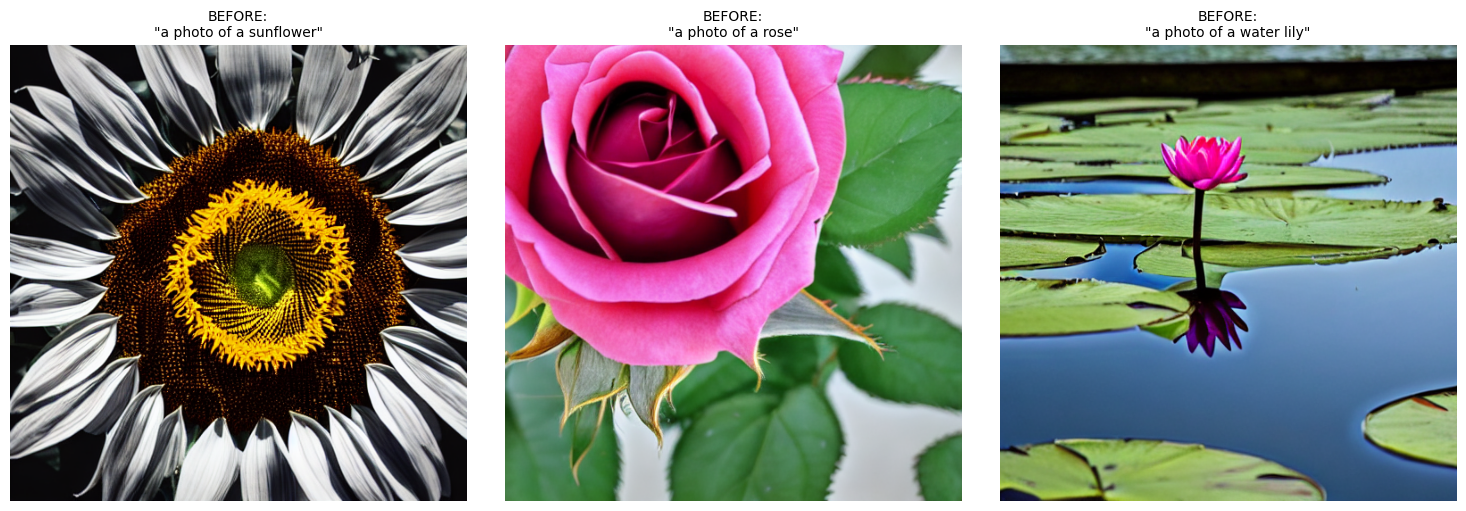

In [11]:
import matplotlib.pyplot as plt

VALIDATION_PROMPTS = [
    'a photo of a sunflower',
    'a photo of a rose',
    'a photo of a water lily',
]

def build_pipeline_from_components():
    pipe = StableDiffusionPipeline.from_pretrained(
        MODEL_NAME,
        vae=vae,
        text_encoder=text_encoder,
        tokenizer=tokenizer,
        unet=unet,
        safety_checker=None,
    ).to(device)
    return pipe

print('Generating BEFORE images...')
pipe = build_pipeline_from_components()
pipe.set_progress_bar_config(disable=True)

generator = torch.Generator(device=device).manual_seed(123)
before_images = [pipe(p, num_inference_steps=25, generator=generator).images[0] for p in VALIDATION_PROMPTS]

fig, axes = plt.subplots(1, len(VALIDATION_PROMPTS), figsize=(15, 5))
for ax, img, prompt in zip(axes, before_images, VALIDATION_PROMPTS):
    ax.imshow(img)
    ax.set_title(f'BEFORE:\n"{prompt}"', fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig('/content/before_finetuning.png', dpi=150)
plt.show()

del pipe
torch.cuda.empty_cache()

In [12]:
import torch.nn.functional as F

NUM_EPOCHS = 15
LEARNING_RATE = 1e-4

optimizer = torch.optim.AdamW(
    [p for p in unet.parameters() if p.requires_grad],
    lr=LEARNING_RATE
)

unet.train()
losses = []

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_loss = 0.0
    for batch in train_dataloader:
        pixel_values = batch['pixel_values'].to(device, dtype=torch.float32)
        input_ids = batch['input_ids'].to(device)

        with torch.no_grad():
            latents = vae.encode(pixel_values).latent_dist.sample()
            latents = latents * vae.config.scaling_factor

        noise = torch.randn_like(latents)
        bsz = latents.shape[0]
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=device).long()
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        with torch.no_grad():
            encoder_hidden_states = text_encoder(input_ids)[0]

        noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample
        loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_dataloader)
    losses.append(avg_loss)
    print(f'Epoch [{epoch}/{NUM_EPOCHS}]  Loss: {avg_loss:.4f}')

print('LoRA fine-tuning complete.')

Epoch [1/15]  Loss: 0.2200
Epoch [2/15]  Loss: 0.2050
Epoch [3/15]  Loss: 0.1620
Epoch [4/15]  Loss: 0.1712
Epoch [5/15]  Loss: 0.1571
Epoch [6/15]  Loss: 0.2019
Epoch [7/15]  Loss: 0.1634
Epoch [8/15]  Loss: 0.1777
Epoch [9/15]  Loss: 0.1292
Epoch [10/15]  Loss: 0.1927
Epoch [11/15]  Loss: 0.1358
Epoch [12/15]  Loss: 0.1975
Epoch [13/15]  Loss: 0.1601
Epoch [14/15]  Loss: 0.1688
Epoch [15/15]  Loss: 0.2104
LoRA fine-tuning complete.


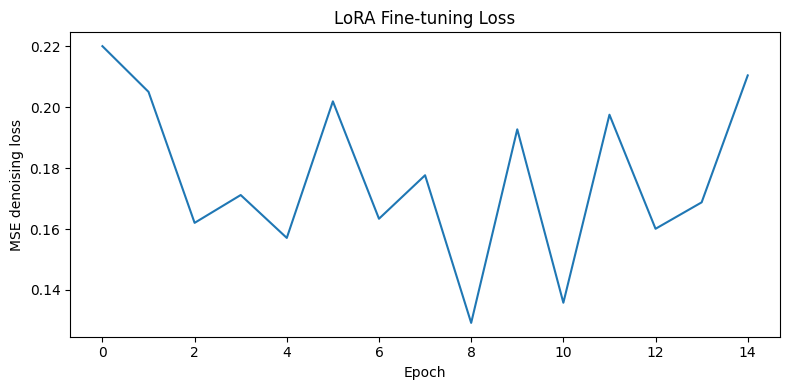

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('MSE denoising loss')
plt.title('LoRA Fine-tuning Loss')
plt.tight_layout()
plt.savefig('/content/lora_training_loss.png', dpi=150)
plt.show()

In [14]:
import shutil

LORA_SAVE_DIR = '/content/lora_weights'
os.makedirs(LORA_SAVE_DIR, exist_ok=True)
unet.save_pretrained(LORA_SAVE_DIR)

size_mb = sum(
    os.path.getsize(os.path.join(LORA_SAVE_DIR, f))
    for f in os.listdir(LORA_SAVE_DIR)
) / (1024 * 1024)
print(f'Saved LoRA weights to {LORA_SAVE_DIR} ({size_mb:.1f} MB total)')

Saved LoRA weights to /content/lora_weights (3.1 MB total)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Expected types for unet: (<class 'diffusers.models.unets.unet_2d_condition.UNet2DConditionModel'>,), got <class 'peft.peft_model.PeftModel'>.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


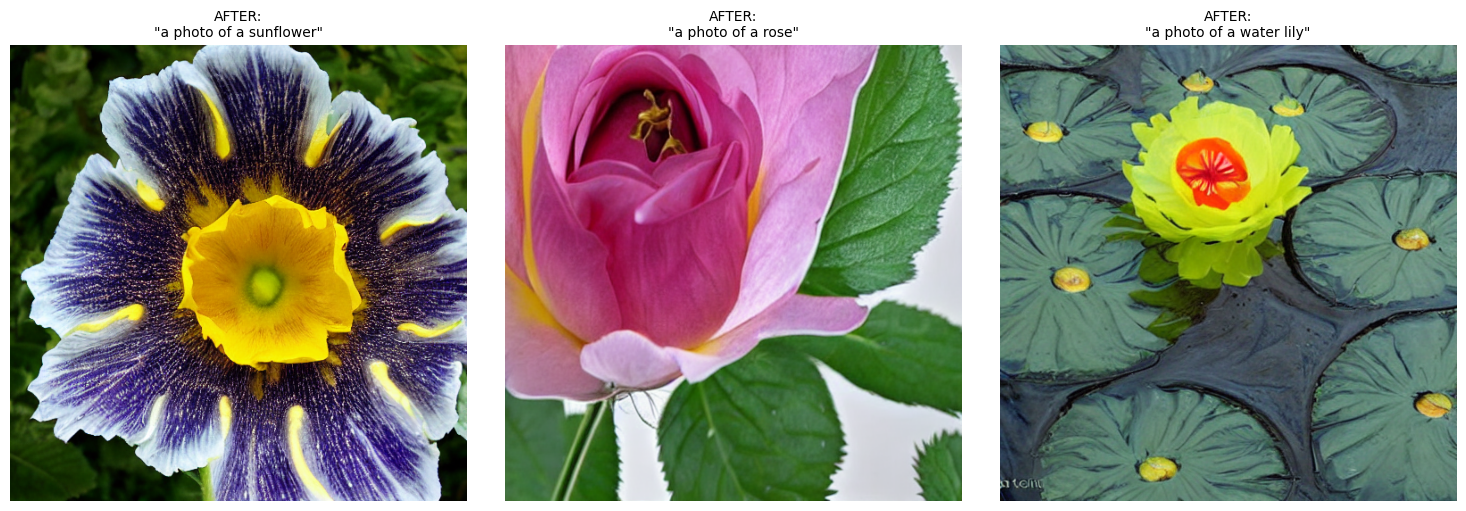

In [15]:
unet.eval()
pipe = build_pipeline_from_components()
pipe.set_progress_bar_config(disable=True)

generator = torch.Generator(device=device).manual_seed(123)
after_images = [pipe(p, num_inference_steps=25, generator=generator).images[0] for p in VALIDATION_PROMPTS]

fig, axes = plt.subplots(1, len(VALIDATION_PROMPTS), figsize=(15, 5))
for ax, img, prompt in zip(axes, after_images, VALIDATION_PROMPTS):
    ax.imshow(img)
    ax.set_title(f'AFTER:\n"{prompt}"', fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig('/content/after_finetuning.png', dpi=150)
plt.show()

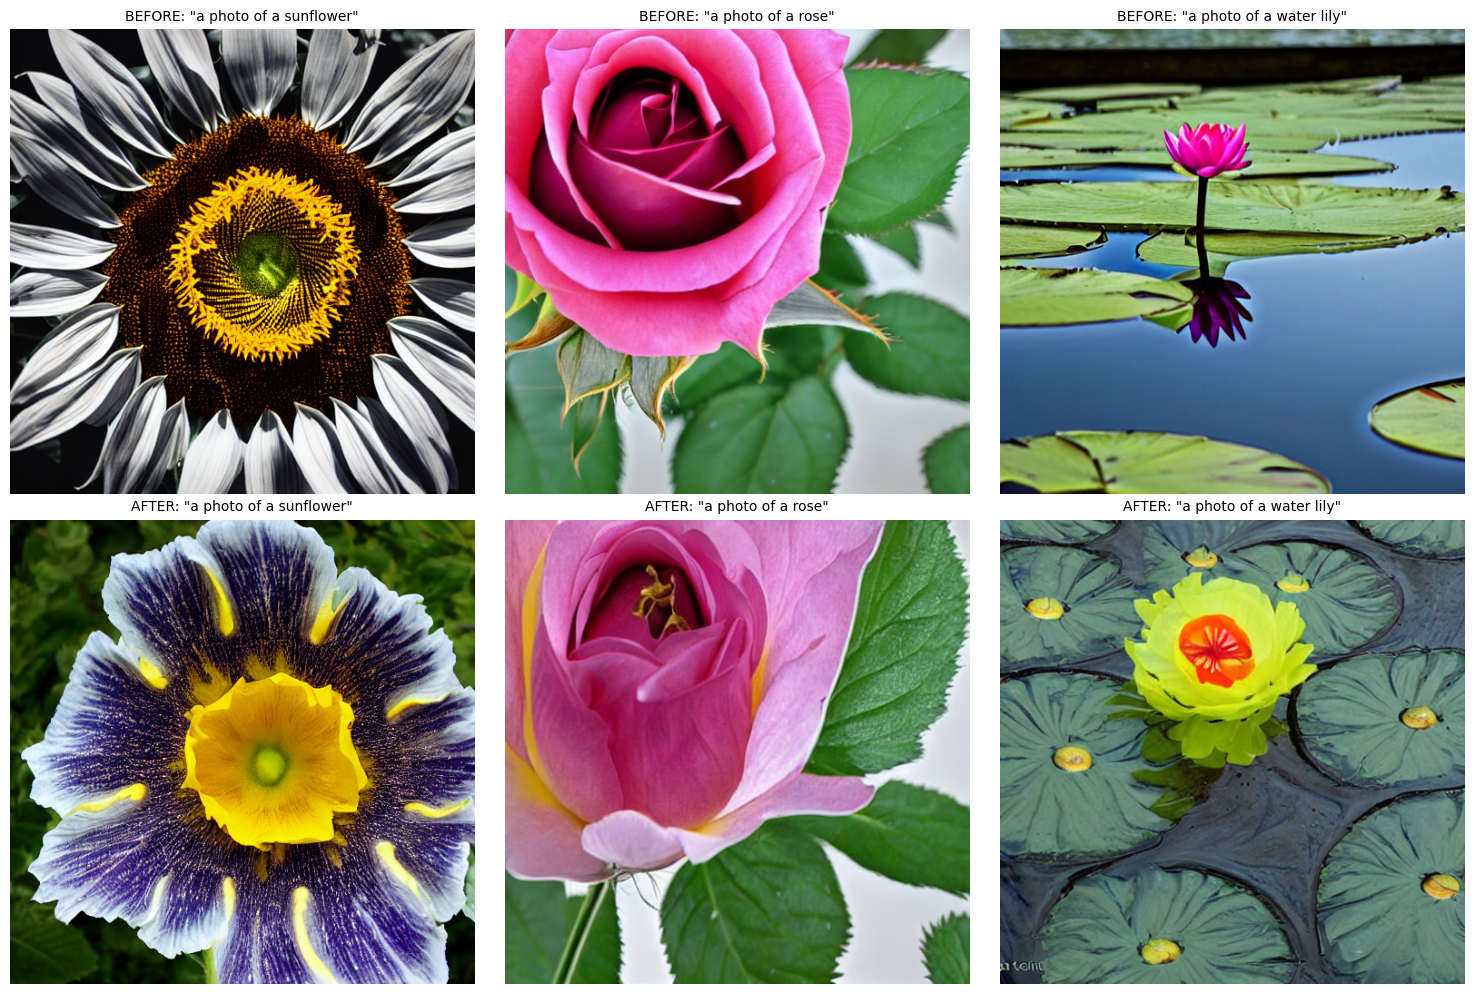

In [16]:
fig, axes = plt.subplots(2, len(VALIDATION_PROMPTS), figsize=(15, 10))
for col, prompt in enumerate(VALIDATION_PROMPTS):
    axes[0, col].imshow(before_images[col])
    axes[0, col].set_title(f'BEFORE: "{prompt}"', fontsize=10)
    axes[0, col].axis('off')
    axes[1, col].imshow(after_images[col])
    axes[1, col].set_title(f'AFTER: "{prompt}"', fontsize=10)
    axes[1, col].axis('off')
plt.tight_layout()
plt.savefig('/content/before_after_comparison.png', dpi=150)
plt.show()

In [17]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/elevance-skills/task1_finetune_diffusion'
os.makedirs(DRIVE_DIR, exist_ok=True)

shutil.copytree(LORA_SAVE_DIR, os.path.join(DRIVE_DIR, 'lora_weights'), dirs_exist_ok=True)
for fname in ['before_finetuning.png', 'after_finetuning.png', 'before_after_comparison.png', 'lora_training_loss.png']:
    src = os.path.join('/content', fname)
    if os.path.exists(src):
        shutil.copy(src, os.path.join(DRIVE_DIR, fname))

print('Copied LoRA weights and result images to:', DRIVE_DIR)
print(os.listdir(DRIVE_DIR))

Mounted at /content/drive
Copied LoRA weights and result images to: /content/drive/MyDrive/elevance-skills/task1_finetune_diffusion
['lora_weights', 'before_finetuning.png', 'after_finetuning.png', 'before_after_comparison.png', 'lora_training_loss.png']
